# Importing libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import Lasso, Ridge

# Data loading & Inspection

In [ ]:
titanic = sns.load_dataset("titanic")

In [ ]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
titanic.describe(include="all")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data Cleaning

In [ ]:
print(titanic.isna().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [ ]:
titanic.fillna({"age": titanic['age'].median()}, inplace=True)

In [ ]:
print(titanic.isna().sum())

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [ ]:
titanic.fillna({"embarked": titanic['embarked'].mode()[0]}, inplace=True)

In [ ]:
titanic.drop(columns=["deck"], inplace=True)

In [ ]:
print(titanic.isna().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


In [ ]:
titanic[['embarked', 'embark_town']].value_counts()

embarked  embark_town
S         Southampton    644
C         Cherbourg      168
Q         Queenstown      77
Name: count, dtype: int64

In [ ]:
titanic.drop(columns='embark_town', inplace=True)

Are the same too, here we can drop one of the two columns.

# Exploratory Data Analysis (EDA)

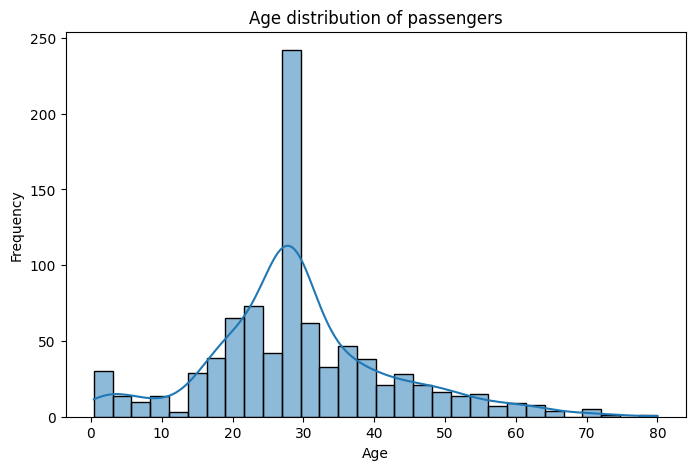

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(titanic['age'], bins=30, kde=True)
plt.title("Age distribution of passengers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

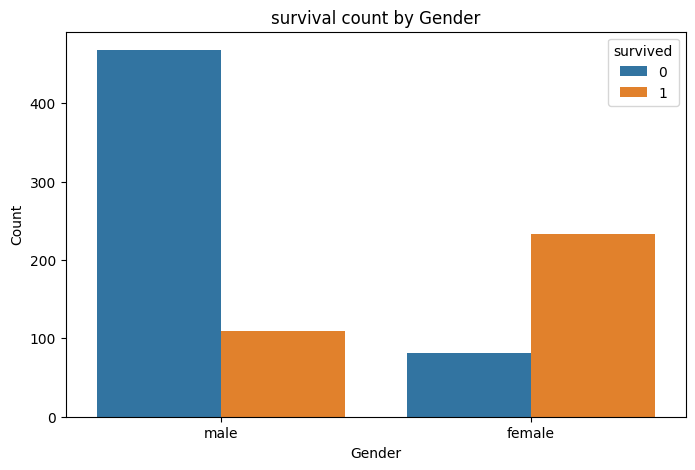

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x="sex", hue="survived", data=titanic)
plt.title("survival count by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

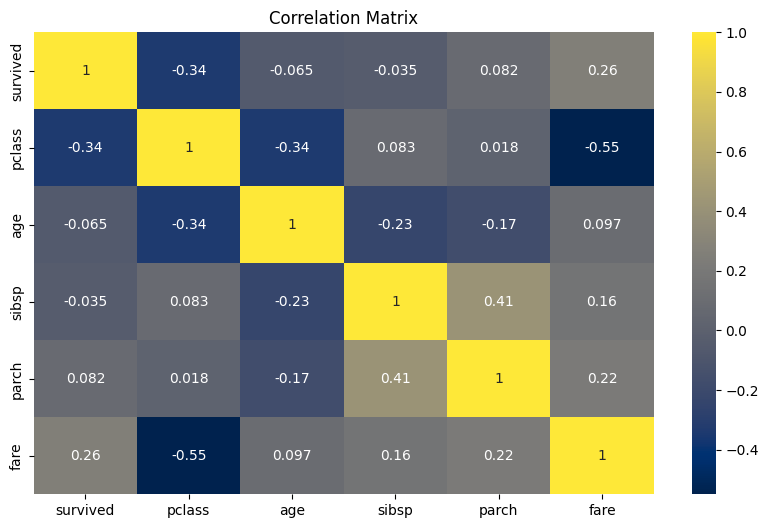

In [ ]:
numerical_feastures = titanic.select_dtypes(include=["float64", "int64"])
corr = numerical_feastures.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, cmap="cividis", annot=True)
plt.title("Correlation Matrix")
plt.show()

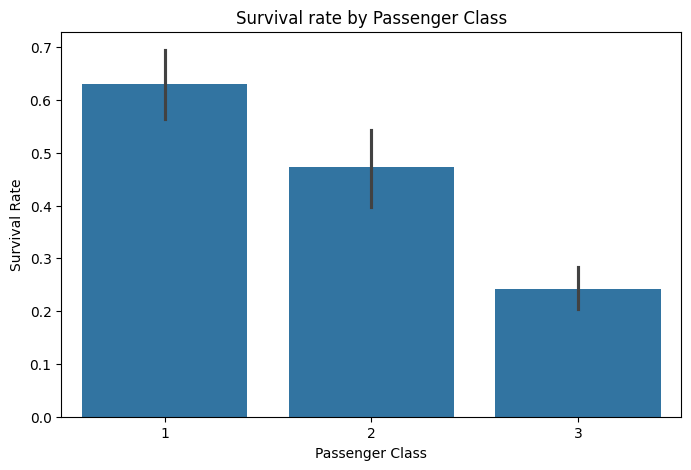

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x="pclass", y="survived", data=titanic)
plt.title("Survival rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

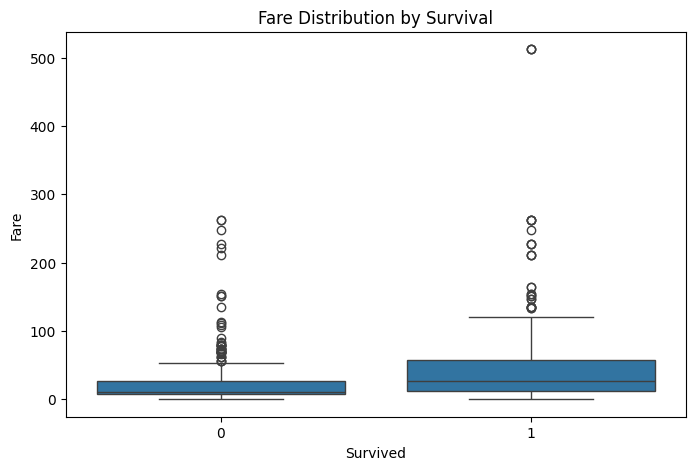

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="survived", y="fare", data=titanic)
plt.title("Fare Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.show()

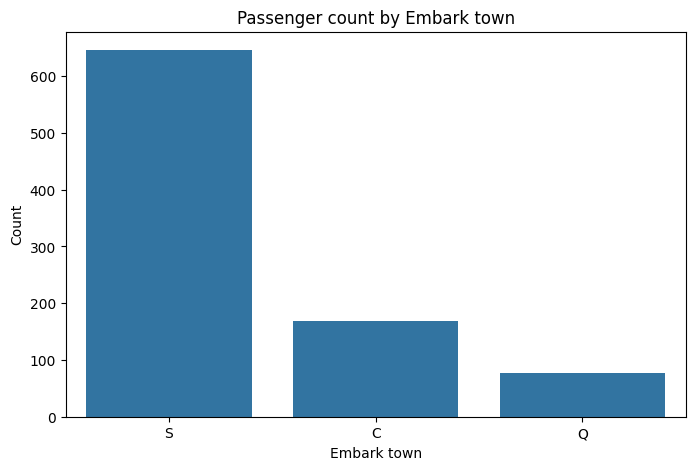

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='embarked', data=titanic)
plt.title('Passenger count by Embark town')
plt.xlabel('Embark town')
plt.ylabel('Count')
plt.show()

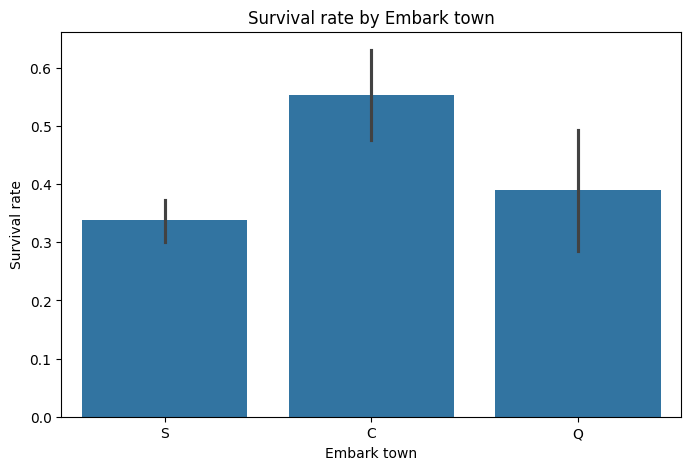

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x='embarked', y='survived', data=titanic)
plt.title('Survival rate by Embark town')
plt.xlabel('Embark town')
plt.ylabel('Survival rate')
plt.show()

# Feature Engineering

In [ ]:
titanic[['survived', 'alive']].value_counts()

survived  alive
0         no       549
1         yes      342
Name: count, dtype: int64

In [ ]:
titanic.drop(columns='alive', inplace=True)

Since the two features ('survived', 'alive') are the same, but we need the numeric one then we can drop the 'alive' column from the dataset.

In [ ]:
titanic[['pclass', 'class']].value_counts()

pclass  class 
3       Third     491
1       First     216
2       Second    184
Name: count, dtype: int64

In [ ]:
titanic.drop(columns='class', inplace=True)

as before since the two features ('pclass', 'class') are the same, but we need the numeric one then we can drop the 'class' column from the dataset.

In [ ]:
titanic[['sex', 'who']].value_counts()

sex     who  
male    man      537
female  woman    271
        child     43
male    child     40
Name: count, dtype: int64

In [ ]:
titanic[['who', 'adult_male']].value_counts()

who    adult_male
man    True          537
woman  False         271
child  False          83
Name: count, dtype: int64

In [ ]:
titanic[['sex', 'adult_male']].value_counts()

sex     adult_male
male    True          537
female  False         314
male    False          40
Name: count, dtype: int64

In [ ]:
titanic['adult_male'].value_counts()

adult_male
True     537
False    354
Name: count, dtype: int64

In [ ]:
titanic['who'].value_counts()

who
man      537
woman    271
child     83
Name: count, dtype: int64

In [ ]:
titanic['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [ ]:
titanic.drop(columns='adult_male', inplace=True)

Remove 'adult_male' column because it's a redandant column we get same meaning from 'who' column.

In [ ]:
titanic["family_size"] = titanic['sibsp'] + titanic['parch']

In [ ]:
print(titanic[["family_size", "alone"]].head())

   family_size  alone
0            1  False
1            1  False
2            0   True
3            1  False
4            0   True


In [ ]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,man,False,1
1,1,1,female,38.0,1,0,71.2833,C,woman,False,1
2,1,3,female,26.0,0,0,7.9250,S,woman,True,0
3,1,1,female,35.0,1,0,53.1000,S,woman,False,1
4,0,3,male,35.0,0,0,8.0500,S,man,True,0


In [ ]:
sex_encoding = pd.get_dummies(titanic['sex'], prefix='sex')
titanic = pd.concat([titanic, sex_encoding], axis=1)
titanic.drop(columns='sex', inplace=True)

In [ ]:
embark_town_encoding = pd.get_dummies(titanic['embarked'], prefix='embarked')
titanic = pd.concat([titanic, embark_town_encoding], axis=1)
titanic.drop(columns=['embarked'], inplace=True)

In [ ]:
who_encoding = pd.get_dummies(titanic['who'], prefix='who')
titanic = pd.concat([titanic, who_encoding], axis=1)
titanic.drop(columns='who', inplace=True)

In [ ]:
titanic.replace({True: 1, False: 0}, inplace=True)

C:\Users\hami1\AppData\Local\Temp\ipykernel_12076\2269117105.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  titanic.replace({True: 1, False: 0}, inplace=True)


In [ ]:
titanic.head()

,survived,pclass,age,sibsp,parch,fare,alone,family_size,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,who_child,who_man,who_woman
0,0,3,22.0,1,0,7.2500,0,1,0,1,0,0,1,0,1,0
1,1,1,38.0,1,0,71.2833,0,1,1,0,1,0,0,0,0,1
2,1,3,26.0,0,0,7.9250,1,0,1,0,0,0,1,0,0,1
3,1,1,35.0,1,0,53.1000,0,1,1,0,0,0,1,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,0,1,0,0,1,0,1,0


# Additional Data Visualizations

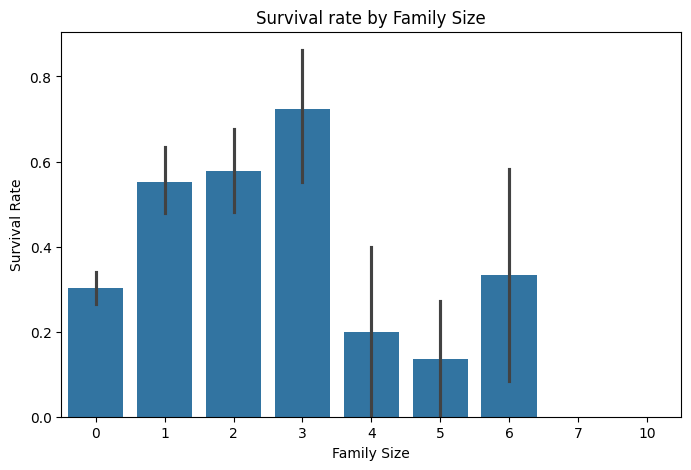

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x="family_size", y="survived", data=titanic)
plt.title("Survival rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.show()

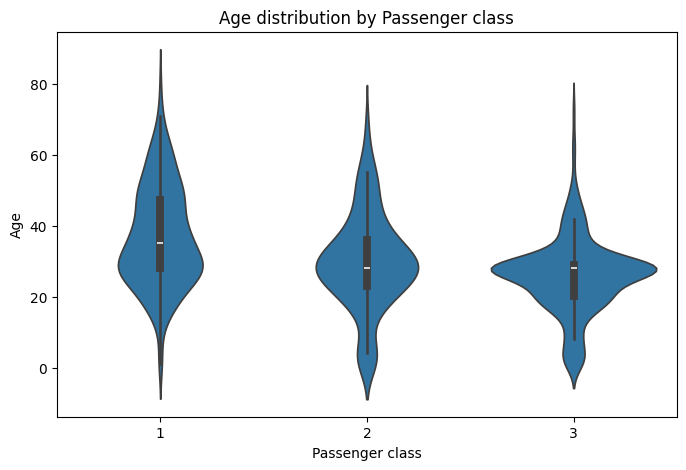

In [ ]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='pclass', y='age', data=titanic)
plt.title('Age distribution by Passenger class')
plt.xlabel('Passenger class')
plt.ylabel('Age')
plt.show()

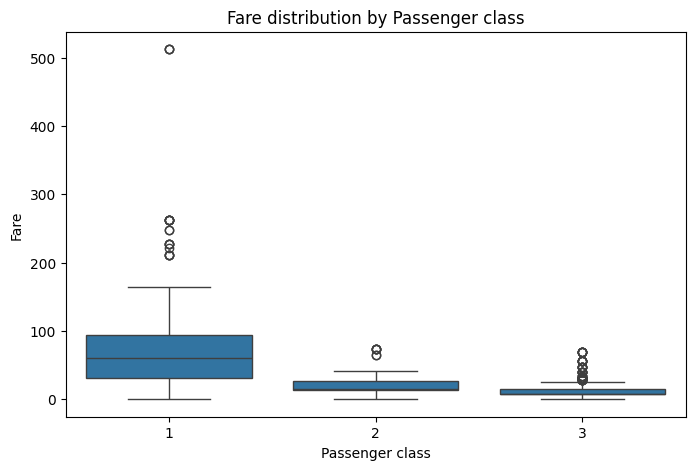

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='pclass', y='fare', data=titanic)
plt.title('Fare distribution by Passenger class')
plt.xlabel('Passenger class')
plt.ylabel('Fare')
plt.show()

In [ ]:
def remove_outliers(data):
    numerical_features = data.select_dtypes(include=['float64', 'int64']).columns
    mask = pd.Series(True, index=data.index)
    for column in numerical_features:
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1
        column_mask = (data[column] >= (Q1 - 1.5 * IQR)) & (data[column] <= (Q3 + 1.5 * IQR))
        mask = mask & column_mask
    return data[mask]

In [ ]:
No_outliers = remove_outliers(titanic)
No_outliers.reset_index(drop=True)

,survived,pclass,age,sibsp,parch,fare,alone,family_size,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,who_child,who_man,who_woman
0,0,3,22.0,1,0,7.2500,0,1,0,1,0,0,1,0,1,0
1,1,3,26.0,0,0,7.9250,1,0,1,0,0,0,1,0,0,1
2,1,1,35.0,1,0,53.1000,0,1,1,0,0,0,1,0,0,1
3,0,3,35.0,0,0,8.0500,1,0,0,1,0,0,1,0,1,0
4,0,1,54.0,0,0,51.8625,1,0,0,1,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426,0,3,22.0,0,0,10.5167,1,0,1,0,0,0,1,0,0,1
427,0,2,28.0,0,0,10.5000,1,0,0,1,0,0,1,0,1,0
428,0,3,25.0,0,0,7.0500,1,0,0,1,0,0,1,0,1,0
429,0,2,27.0,0,0,13.0000,1,0,0,1,0,0,1,0,1,0


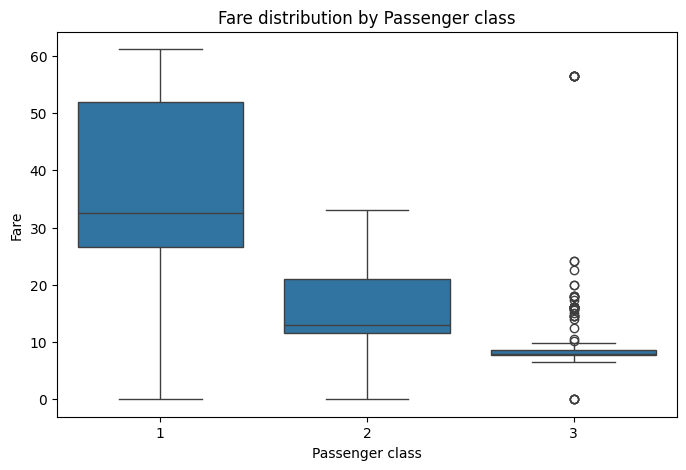

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='pclass', y='fare', data=No_outliers)
plt.title('Fare distribution by Passenger class')
plt.xlabel('Passenger class')
plt.ylabel('Fare')
plt.show()

In [ ]:
scaler = StandardScaler()

titanic[['age_standard', 'fare_standard']] = scaler.fit_transform(titanic[['age', 'fare']])

titanic.drop(['age', 'fare'], axis=1, inplace=True)

In [ ]:
titanic.head()

,survived,pclass,sibsp,parch,alone,family_size,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,who_child,who_man,who_woman,age_standard,fare_standard
0,0,3,1,0,0,1,0,1,0,0,1,0,1,0,-0.565736,-0.502445
1,1,1,1,0,0,1,1,0,1,0,0,0,0,1,0.663861,0.786845
2,1,3,0,0,1,0,1,0,0,0,1,0,0,1,-0.258337,-0.488854
3,1,1,1,0,0,1,1,0,0,0,1,0,0,1,0.433312,0.420730
4,0,3,0,0,1,0,0,1,0,0,1,0,1,0,0.433312,-0.486337


# Summary of Analysis

*   **Age Distribution**: Most passengers were young adults, with a significant number of children and elderly individuals.

*   **Gender and Survival**: Women had a higher survival rate compared to men, reflecting the "women and children first" policy.

*   **Passenger Class and Survival**: First-class passengers had higher survival rates than those in lower classes, showing a class-based disparity in survival chances.

*   **Fare Influence**: Higher fare payments correlated with better survival odds, likely due to better access to lifeboats.
*   List item


*   **Family Size and Survival**: Moderate family sizes had higher survival rates; passengers traveling alone had lower survival chances.


*   **Embarkation Town**: Passengers who embarked at certain towns had varying survival rates, potentially reflecting different socioeconomic backgrounds.

In [ ]:
X = titanic.drop('survived', axis=1)
Y = titanic['survived']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [ ]:
log_reg = LogisticRegression()
log_reg.fit(x_train, y_train)

DT = DecisionTreeClassifier()
DT.fit(x_train, y_train)

NB = GaussianNB()
NB.fit(x_train, y_train)

,priors,None
,var_smoothing,1e-09


In [ ]:
y_train_pred_log_reg = log_reg.predict(x_train)
y_train_pred_DT = DT.predict(x_train)
y_train_pred_NB = NB.predict(x_train)

In [ ]:
y_pred_log_reg = log_reg.predict(x_test)
y_pred_DT = DT.predict(x_test)
y_pred_NB = NB.predict(x_test)

In [ ]:
print(f'{confusion_matrix(y_train, y_train_pred_log_reg)}')
print(f'\n{confusion_matrix(y_train, y_train_pred_DT)}')
print(f'\n{confusion_matrix(y_train, y_train_pred_NB)}')

[[346  46]
 [ 61 170]]

[[391   1]
 [ 11 220]]

[[331  61]
 [ 55 176]]


In [ ]:
print(f'{confusion_matrix(y_test, y_pred_log_reg)}')
print(f'\n{confusion_matrix(y_test, y_pred_DT)}')
print(f'\n{confusion_matrix(y_test, y_pred_NB)}')

[[137  20]
 [ 29  82]]

[[127  30]
 [ 38  73]]

[[131  26]
 [ 30  81]]


In [ ]:
print(f'{classification_report(y_train, y_train_pred_log_reg)}')
print(f'\n{classification_report(y_train, y_train_pred_DT)}')
print(f'\n{classification_report(y_train, y_train_pred_NB)}')

              precision    recall  f1-score   support

           0       0.85      0.88      0.87       392
           1       0.79      0.74      0.76       231

    accuracy                           0.83       623
   macro avg       0.82      0.81      0.81       623
weighted avg       0.83      0.83      0.83       623


              precision    recall  f1-score   support

           0       0.97      1.00      0.98       392
           1       1.00      0.95      0.97       231

    accuracy                           0.98       623
   macro avg       0.98      0.97      0.98       623
weighted avg       0.98      0.98      0.98       623


              precision    recall  f1-score   support

           0       0.86      0.84      0.85       392
           1       0.74      0.76      0.75       231

    accuracy                           0.81       623
   macro avg       0.80      0.80      0.80       623
weighted avg       0.81      0.81      0.81       623



In [ ]:
print(f'{classification_report(y_test, y_pred_log_reg)}')
print(f'\n{classification_report(y_test, y_pred_DT)}')
print(f'\n{classification_report(y_test, y_pred_NB)}')

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       157
           1       0.80      0.74      0.77       111

    accuracy                           0.82       268
   macro avg       0.81      0.81      0.81       268
weighted avg       0.82      0.82      0.82       268


              precision    recall  f1-score   support

           0       0.77      0.81      0.79       157
           1       0.71      0.66      0.68       111

    accuracy                           0.75       268
   macro avg       0.74      0.73      0.74       268
weighted avg       0.74      0.75      0.74       268


              precision    recall  f1-score   support

           0       0.81      0.83      0.82       157
           1       0.76      0.73      0.74       111

    accuracy                           0.79       268
   macro avg       0.79      0.78      0.78       268
weighted avg       0.79      0.79      0.79       268



In [ ]:
log_reg_rid = LogisticRegression(C=0.1)
log_reg_rid.fit(x_train, y_train)
y_pred_log_reg_rid = log_reg_rid.predict(x_test)

print(f'{confusion_matrix(y_test, y_pred_log_reg_rid)}')
print(f'\n{classification_report(y_test, y_pred_log_reg_rid)}')

[[137  20]
 [ 31  80]]

              precision    recall  f1-score   support

           0       0.82      0.87      0.84       157
           1       0.80      0.72      0.76       111

    accuracy                           0.81       268
   macro avg       0.81      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268



In [ ]:
DT_tune = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5)
DT_tune.fit(x_train, y_train)
y_pred_DT_tune = DT_tune.predict(x_test)

print(f'{confusion_matrix(y_test, y_pred_DT_tune)}')
print(f'\n{classification_report(y_test, y_pred_DT_tune)}')

[[140  17]
 [ 30  81]]

              precision    recall  f1-score   support

           0       0.82      0.89      0.86       157
           1       0.83      0.73      0.78       111

    accuracy                           0.82       268
   macro avg       0.83      0.81      0.82       268
weighted avg       0.82      0.82      0.82       268

